In [1]:
%cd /home/sazhang/Tokenized-Neural-Rendering

/home/sazhang/Tokenized-Neural-Rendering


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

from model.renderer import TransformerRF
from model.tri_token_model import TriangleEncoder
from pipeline.simple_dataset import SingleObjectDataset


In [3]:
# --- Quick Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Instantiate Decoder simple for faster training for now
token_dim = 128
decoder = TransformerRF(token_dim=token_dim, num_layers=2, nhead=4, num_freqs=3).to(device)
decoder.train()

# 2. Create a "Dummy Encoder" (just a learnable vector)
# This mimics what the PointNet WOULD output for a single object
# We use nn.Parameter so the optimizer can update it
dummy_object_code = nn.Parameter(torch.randn(1, token_dim).to(device) * 0.1)

# 3. Optimizer (Optimize BOTH the decoder weights AND the object code)
# optimizer = torch.optim.AdamW([
#     {'params': decoder.parameters()},
#     {'params': dummy_object_code} 
# ], lr=4e-3)
# MUCH higher learning rate
optimizer = torch.optim.AdamW([
    {'params': decoder.parameters(), 'lr': 5e-3},
    {'params': dummy_object_code, 'lr': 1e-2}
])

In [ ]:

# 1. Initialize Dataset
dataset = SingleObjectDataset(npz_path='experiment_data_train.npz', device='cuda')

# 2. Initialize DataLoader
dataloader = DataLoader(
    dataset, 
    batch_size=512,  # Number of rays per training step
    shuffle=True,     # Mixes pixels from different views/regions
    num_workers=0     # Keep 0 if data is already on GPU (device='cuda')
)

Dataset loaded: 327680 rays
RGB range: [0.000, 1.000]
RGB mean: 0.103
Foreground pixels: 68927.0 (21.0%)
Foreground weight: 3.75x


## Data inspection

=== DETAILED DATA DIAGNOSTICS ===

Sample 0:
  RGB range: [0.000, 0.000]
  RGB mean: 0.000
  RGB unique values: 1

Sample 1:
  RGB range: [0.000, 0.000]
  RGB mean: 0.000
  RGB unique values: 1

Sample 2:
  RGB range: [0.000, 0.000]
  RGB mean: 0.000
  RGB unique values: 1

Sample 3:
  RGB range: [0.000, 0.000]
  RGB mean: 0.000
  RGB unique values: 1

Sample 4:
  RGB range: [0.000, 0.000]
  RGB mean: 0.000
  RGB unique values: 1

=== BATCH VISUALIZATION ===
Batch size: 512
RGB range: [0.000, 1.000]
RGB mean: 0.096
Num zeros: 1234 / 1536
Num non-zeros: 302 / 1536


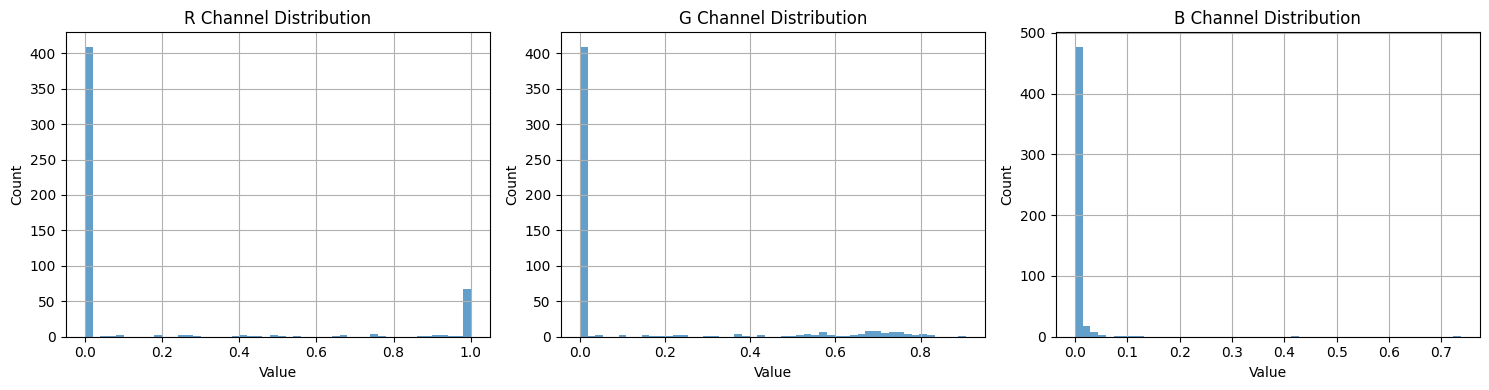

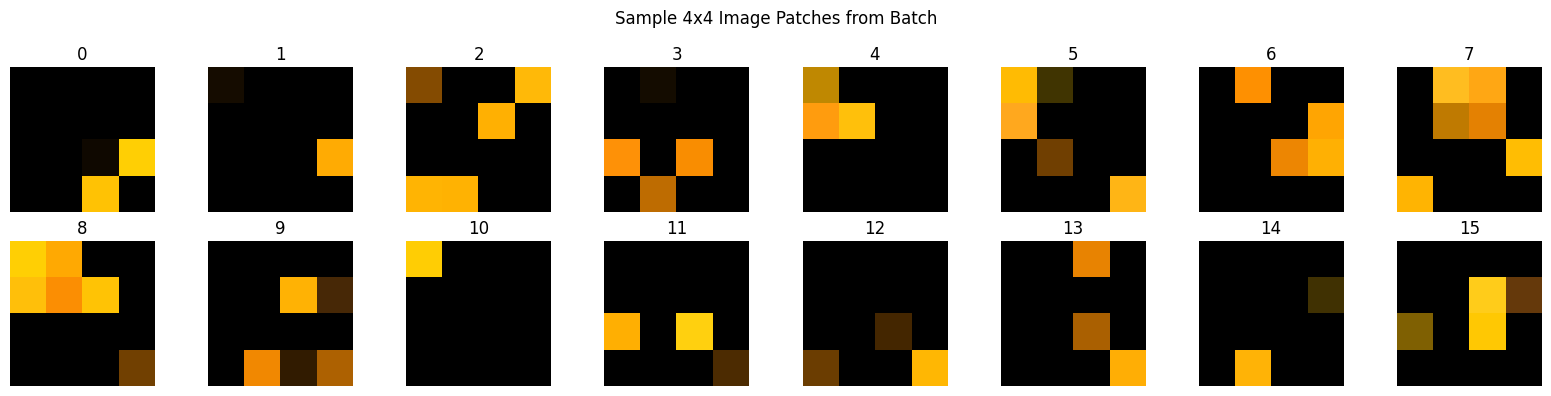


Images saved: rgb_distribution.png, sample_patches.png


In [5]:
# VISUALIZATION: Check what the data actually looks like
import matplotlib.pyplot as plt

print("=== DETAILED DATA DIAGNOSTICS ===")

# Check multiple samples
for i in range(5):
    sample = dataset[i]
    print(f"\nSample {i}:")
    print(f"  RGB range: [{sample['rgb'].min():.3f}, {sample['rgb'].max():.3f}]")
    print(f"  RGB mean: {sample['rgb'].mean():.3f}")
    print(f"  RGB unique values: {len(torch.unique(sample['rgb']))}")

# Visualize the actual data
batch = next(iter(dataloader))
print(f"\n=== BATCH VISUALIZATION ===")
print(f"Batch size: {batch['rgb'].shape[0]}")
print(f"RGB range: [{batch['rgb'].min():.3f}, {batch['rgb'].max():.3f}]")
print(f"RGB mean: {batch['rgb'].mean():.3f}")
print(f"Num zeros: {(batch['rgb'] == 0).sum().item()} / {batch['rgb'].numel()}")
print(f"Num non-zeros: {(batch['rgb'] != 0).sum().item()} / {batch['rgb'].numel()}")

# Plot histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, color in enumerate(['R', 'G', 'B']):
    axes[i].hist(batch['rgb'][:, i].cpu().numpy(), bins=50, alpha=0.7)
    axes[i].set_title(f'{color} Channel Distribution')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('rgb_distribution.png')
plt.show()

# Visualize actual images from batch
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    ax = axes[i // 8, i % 8]
    # Take 16 consecutive pixels and reshape to 4x4
    if i * 16 < len(batch['rgb']):
        pixels = batch['rgb'][i*16:(i+1)*16].cpu().numpy()
        if len(pixels) == 16:
            img = pixels.reshape(4, 4, 3)
            ax.imshow(img.clip(0, 1))
    ax.axis('off')
    ax.set_title(f'{i}')

plt.suptitle('Sample 4x4 Image Patches from Batch')
plt.tight_layout()
plt.savefig('sample_patches.png')
plt.show()

print("\nImages saved: rgb_distribution.png, sample_patches.png")

In [6]:
# Load and inspect the NPZ file directly
import numpy as np

data = np.load('experiment_data.npz')
print("\n=== NPZ FILE CONTENTS ===")
print(f"Keys: {list(data.keys())}")

for key in data.keys():
    arr = data[key]
    print(f"\n{key}:")
    print(f"  Shape: {arr.shape}")
    print(f"  Dtype: {arr.dtype}")
    print(f"  Range: [{arr.min():.3f}, {arr.max():.3f}]")
    print(f"  Mean: {arr.mean():.3f}")
    print(f"  Num zeros: {(arr == 0).sum()} / {arr.size}")
    
# Visualize one full image
if 'rgb_pixels' in data:
    rgb = data['rgb_pixels']
    # Reshape to image grid (assuming square images)
    n_pixels = rgb.shape[0]
    img_size = int(np.sqrt(n_pixels))
    
    if img_size * img_size == n_pixels:
        img = rgb.reshape(img_size, img_size, 3)
        plt.figure(figsize=(8, 8))
        plt.imshow(img.clip(0, 1))
        plt.title('Full Image from NPZ')
        plt.axis('off')
        plt.savefig('full_image.png')
        plt.show()
        print(f"\nFull image saved: full_image.png ({img_size}x{img_size})")


=== NPZ FILE CONTENTS ===
Keys: ['rgb', 'rays_o', 'rays_d']

rgb:
  Shape: (20, 128, 128, 3)
  Dtype: uint8
  Range: [0.000, 255.000]
  Mean: 26.300
  Num zeros: 780183 / 983040

rays_o:
  Shape: (20, 128, 128, 3)
  Dtype: float64
  Range: [-1.643, 1.493]
  Mean: -0.404
  Num zeros: 0 / 983040

rays_d:
  Shape: (20, 128, 128, 3)
  Dtype: float64
  Range: [-1.000, 1.000]
  Mean: -0.006
  Num zeros: 0 / 983040


## Training loop

In [ ]:
num_epochs = 50  # Start with 50, increase if needed
# criterion = nn.MSELoss()
# Initialize TensorBoard writer
log_time = datetime.now().strftime("%m-%d_%H:%M")
log_name = f'bunny_experiment_{log_time}'
writer = SummaryWriter(f'runs/{log_name}')

print(f"Total rays: {len(dataset)}, Batch size: 1024")
print(f"Steps per epoch: {len(dataloader)}")
print(f"TensorBoard logs: runs/{log_name}")
print(f"Run: tensorboard --logdir=runs")

global_step = 0

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch_idx, batch in enumerate(dataloader):
        optimizer.zero_grad()

        rays_o = batch['rays_o'].to(device)
        rays_d = batch['rays_d'].to(device) # negate or not???
        target_rgb = batch['rgb'].to(device)
        weights = batch['weight'].to(device)  # NEW

        batch_code = dummy_object_code.expand(rays_o.shape[0], -1)
        pred_rgb = decoder(batch_code, rays_o, rays_d)
        
        # loss = criterion(pred_rgb, target_rgb)
        # Weighted MSE loss
        pixel_loss = ((pred_rgb - target_rgb) ** 2).mean(dim=1)  # [B]
        loss = (pixel_loss * weights).mean()  # Weighted average
        
        loss.backward()

        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)        
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # Log to TensorBoard every step
        writer.add_scalar('Loss/train_step', loss.item(), global_step)
        
        # Log learning rate
        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar('Learning_Rate', current_lr, global_step)
        
        global_step += 1
    
    # Epoch-level logging
    avg_loss = epoch_loss / len(dataloader)
    writer.add_scalar('Loss/train_epoch', avg_loss, epoch)
    
    # Log parameter statistics
    writer.add_scalar('Stats/dummy_code_norm', 
                     torch.norm(dummy_object_code).item(), epoch)
    
    # Log gradient norms
    total_grad_norm = 0.0
    for p in decoder.parameters():
        if p.grad is not None:
            total_grad_norm += p.grad.norm().item() ** 2
    total_grad_norm = total_grad_norm ** 0.5
    writer.add_scalar('Stats/gradient_norm', total_grad_norm, epoch)
    
    # Log sample predictions vs ground truth (every 10 epochs)
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            sample_batch = next(iter(dataloader))
            
            # Use 256 samples for a 16x16 grid (easier to see than 4x4)
            n_vis = 256
            if len(sample_batch['rgb']) >= n_vis:
                sample_rays_o = sample_batch['rays_o'][:n_vis].to(device)
                sample_rays_d = sample_batch['rays_d'][:n_vis].to(device)  
                sample_target = sample_batch['rgb'][:n_vis].to(device)
                
                sample_code = dummy_object_code.expand(n_vis, -1)
                sample_pred = decoder(sample_code, sample_rays_o, sample_rays_d)
                
                # Reshape to 16x16 grids [C, H, W]
                pred_img = sample_pred.reshape(16, 16, 3).permute(2, 0, 1)
                gt_img = sample_target.reshape(16, 16, 3).permute(2, 0, 1)
                
                # Concatenate horizontally: Pred (Left) | GT (Right)
                combined_img = torch.cat([pred_img, gt_img], dim=2)
                
                writer.add_image('Comparison_Pred_vs_GT', combined_img, epoch)
    

    # Log full image reconstructions (every 10 epochs)
    if (epoch + 1) % 10 == 0:
        decoder.eval()
        with torch.no_grad():
            H, W = 128, 128
            pixels_per_view = H * W
            
            # --- 1. Render Training View (First view of train set) ---
            train_o = dataset_train.rays_o[:pixels_per_view]
            train_d = dataset_train.rays_d[:pixels_per_view]
            train_gt = dataset_train.rgb_pixels[:pixels_per_view]
            
            train_code = dummy_object_code.expand(pixels_per_view, -1)
            train_pred = decoder(train_code, train_o, train_d)
            
            img_train = torch.cat([
                train_pred.reshape(H, W, 3).permute(2, 0, 1),
                train_gt.reshape(H, W, 3).permute(2, 0, 1)
            ], dim=2)
            
            # --- 2. Render Validation View (First view of val set) ---
            val_o = dataset_val.rays_o[:pixels_per_view]
            val_d = dataset_val.rays_d[:pixels_per_view]
            val_gt = dataset_val.rgb_pixels[:pixels_per_view]
            
            val_code = dummy_object_code.expand(pixels_per_view, -1)
            val_pred = decoder(val_code, val_o, val_d)
            
            img_val = torch.cat([
                val_pred.reshape(H, W, 3).permute(2, 0, 1),
                val_gt.reshape(H, W, 3).permute(2, 0, 1)
            ], dim=2)
            
            writer.add_image('Full_Recon/Train_View', img_train, epoch)
            writer.add_image('Full_Recon/Val_View', img_val, epoch)
            
        decoder.train()
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.6f}')

writer.close()

print("\nTraining complete!")


Total rays: 327680, Batch size: 1024
Steps per epoch: 640
TensorBoard logs: runs/bunny_experiment_12-09_10:57
Run: tensorboard --logdir=runs
Epoch 5/50 | Loss: 0.019335
Epoch 10/50 | Loss: 0.016435
Epoch 15/50 | Loss: 0.015063
Epoch 20/50 | Loss: 0.013978
Epoch 25/50 | Loss: 0.013640
Epoch 30/50 | Loss: 0.013105
Epoch 35/50 | Loss: 0.012776
Epoch 40/50 | Loss: 0.012465
Epoch 45/50 | Loss: 0.012516
Epoch 50/50 | Loss: 0.012210

Training complete!


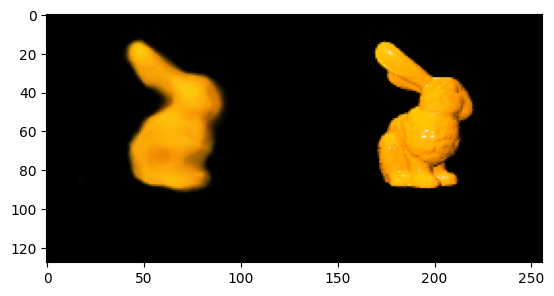

In [ ]:
with torch.no_grad():
    H, W = 128, 128
    pixels_per_view = H * W
    
    # --- 1. Render Training View (First view of train set) ---
    train_o = dataset.rays_o[:pixels_per_view]
    train_d = dataset.rays_d[:pixels_per_view]
    train_gt = dataset.rgb_pixels[:pixels_per_view]
    
    train_code = dummy_object_code.expand(pixels_per_view, -1)
    train_pred = decoder(train_code, train_o, train_d)
    
    img_train = torch.cat([
        train_pred.reshape(H, W, 3).permute(2, 0, 1),
        train_gt.reshape(H, W, 3).permute(2, 0, 1)
    ], dim=2)
    plt.imshow(img_train.permute(1, 2, 0).cpu().numpy())
    
    # --- 2. Render Validation View (First view of val set) ---
    val_o = dataset_val.rays_o[:pixels_per_view]
    val_d = dataset_val.rays_d[:pixels_per_view]
    val_gt = dataset_val.rgb_pixels[:pixels_per_view]
    
    val_code = dummy_object_code.expand(pixels_per_view, -1)
    val_pred = decoder(val_code, val_o, val_d)
    
    img_val = torch.cat([
        val_pred.reshape(H, W, 3).permute(2, 0, 1),
        val_gt.reshape(H, W, 3).permute(2, 0, 1)
    ], dim=2)
            